In [136]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 15

In [152]:
session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"]

exp_nickname = ['JAL004_2024_09_03', 'JAL004_2024_09_19', 'JAL004_2024_08_28', 'JAL004_2024_09_11',
                'JAL005_2024_09_08', 'JAL005_2024_09_21',
                'JAL006_2024_03_28', 'JAL006_2024_03_21', 'JAL006_2024_03_18', 'JAL006_2024_03_25',
                'JAL007_2024_04_09', 'JAL007_2024_03_22', 'JAL007_2024_03_12', 'JAL007_2024_04_16', 'JAL007_2024_04_23',
                'JAL008_2024_04_25', 'JAL008_2024_04_29', 'JAL008_2024_05_07', 'JAL008_2024_05_14', 'JAL008_2024_05_10']

e = 6
session_name = session_names[e]

In [153]:
"""Load the dataset"""
save_path = "Z:\Jasmine_Laurence\summary_plots\Replay\SSdecoder"
cond_names = ['shelter_only', 'barrier', 'barrier_flip']
cond = 2
# load time, position, bin_width and spikes
data = np.load(save_path + '\\' + session_name + '_' + cond_names[cond] + '_state_space_decoder_data.npz')
time = data['time']
position = data['position']
bin_width = data['bin_width'] 
spikes = data['spikes'].T
tuning_curves = data['tuning_curve']
h_start = data['h_start']
sampling_frequency = 1000

In [154]:
import warnings
np.warnings = warnings
from replay_trajectory_classification import (
    SortedSpikesClassifier, Environment, RandomWalk,
    Uniform, Identity)

linear_track_env = Environment(
                            place_bin_size=1,  # Adjust based on your actual bin size
                            # track_graph=my_linear_graph,  # Define a linear graph with 25 nodes
                            edge_order=[(i, i + 1) for i in range(24)],  # Sequential edges
                            edge_spacing=None,  # No gaps between edges
                            position_range=[(0, 25)],  # 0 to 100% of escape route
                            infer_track_interior=False,  # Data is already binned
                            fill_holes=False,
                            dilate=False,
                            bin_count_threshold=1,
                        )

continuous_transition_types = [[RandomWalk(movement_var=1, environment_name=linear_track_env, use_diffusion=True),  Uniform(environment_name=linear_track_env), Identity(environment_name=linear_track_env)],
                                [Uniform(environment_name=linear_track_env), Uniform(environment_name=linear_track_env), Uniform(environment_name=linear_track_env)],
                                [RandomWalk(movement_var=1, environment_name=linear_track_env, use_diffusion=True), Uniform(environment_name=linear_track_env), Identity(environment_name=linear_track_env)],
                               ]

classifier = SortedSpikesClassifier(
                                    environments=linear_track_env,
                                    continuous_transition_types=continuous_transition_types,
                                    sorted_spikes_algorithm='spiking_likelihood_kde',
                                    sorted_spikes_algorithm_params={'block_size': None,
                                                                    'position_std': [6.0], # 3 default, 1 from decoder
                                                                    'use_diffusion': False},
                                    )

classifier.fit(position, spikes)

SortedSpikesClassifier(continuous_transition_types=[[RandomWalk(environment_name=Environment(environment_name='',
                                                                                             place_bin_size=1,
                                                                                             track_graph=None,
                                                                                             edge_order=[(0,
                                                                                                          1),
                                                                                                         (1,
                                                                                                          2),
                                                                                                         (2,
                                                                                                          3),
                                                                                                         (3,
                                                                                                          4),
                                                                                                         (4,
                                                                                                          5),
                                                                                                         (5,
                                                                                                          6),
                                                                                                         (6,
                                                                                                          7),
                                                                                                         (7,
                                                                                                          8),
                                                                                                         (8,
                                                                                                          9),
                                                                                                         (9,
                                                                                                          10),
                                                                                                         (10,
                                                                                                          11),
                                                                                                         (11,
                                                                                                          12),
                                                                                                         (12,
                                                                                                          13),
                                                                                                         (13,
                                                                                                          14),
                                                                                                         (14,
                                                                                                          15),
                                                                                                         (15,
                                                                                                          16),
                                                                                                         (16,
                                     

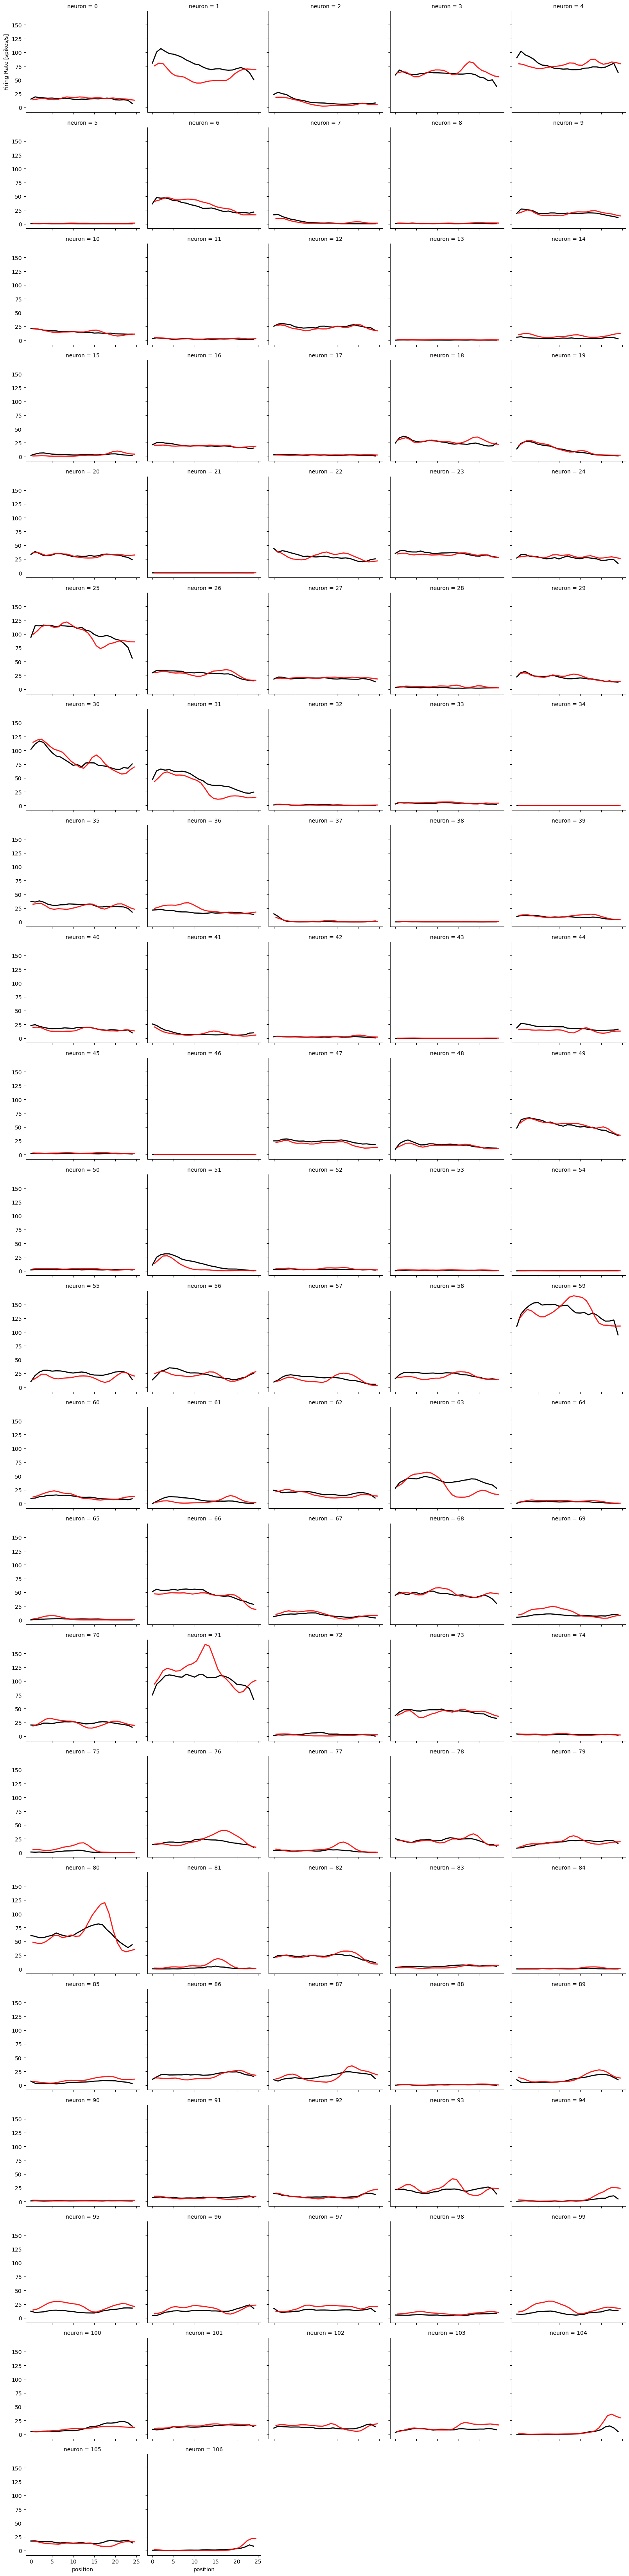

In [7]:
"""Look at the escape tuning"""
g = (classifier.place_fields_['', 0] * sampling_frequency).plot(
        x="position", col="neuron", col_wrap=5, color="red", linewidth=2, alpha=0.9, zorder=1, label="Predicted")
g.axes[0, 0].set_ylabel("Firing Rate [spikes/s]")
for ax, place_field in zip(g.axes.flat, tuning_curves):
    ax.plot(np.arange(25), place_field, linewidth=2, color="black", zorder=-1, label="True")
sns.despine()

In [165]:
STATE_COLORS = {
    'stationary': '#9f043a',
    'fragmented': '#ff6944',
    'continuous': '#521b65',
    'stationary-continuous-mix': '#61c5e6',
    'fragmented-continuous-mix': '#2a586a',
    '': '#c7c7c7',
}

from matplotlib import gridspec

def plot_classification(replay_time, test_spikes, results, h_start):
    fig, axes = plt.subplots(3, 1, figsize=(15, 6), sharex=True, constrained_layout=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # plot the spikes
    spike_time_ind, neuron_ind = np.nonzero(test_spikes)
    ax0 = axes[0]
    ax0.scatter(replay_time[spike_time_ind], neuron_ind, color='black', s=.2, alpha = .2, zorder = 1)
    ax0.set_yticks((0, test_spikes.shape[1]))
    ax0.set_ylabel('Neuron Index')

    # plot the replay state prediction
    ax1 = axes[1]
    replay_probability = results.acausal_posterior.sum('position')
    for state, prob in replay_probability.groupby('state'):
        ax1.plot(prob.time, prob.values, linewidth=2, label=state, color=STATE_COLORS[state])
    ax1.set_ylabel('Probability')
    ax1.set_yticks([0, 1])
    ax1.set_ylim((-0.01, 1.05))
    ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper right', fancybox=False, shadow=False,
                   ncol=1, frameon=False)
    
    # plot the posterior
    ax2 = axes[2]
    im = results.acausal_posterior.sum('state').plot(x="time", y="position", ax=ax2, cmap="bone_r", vmin = 0, vmax = .2, clip_on=False, add_colorbar=False)
    cbar = fig.colorbar(im, ax=ax2, orientation='vertical', fraction=0.02, pad=0.005)
    cbar.set_label('Posterior Probability')
    ax2.set_ylabel('Position [cm]')
    ax2.set_xlabel('Time [ms]')
    
    if len(h_start) > 0:
        for h in h_start:
            ax0.axvline(h*bin_width, color='red', linestyle='--', linewidth=1)
            ax2.axvline(h*bin_width, color='red', linestyle='--', linewidth=1)

    sns.despine()

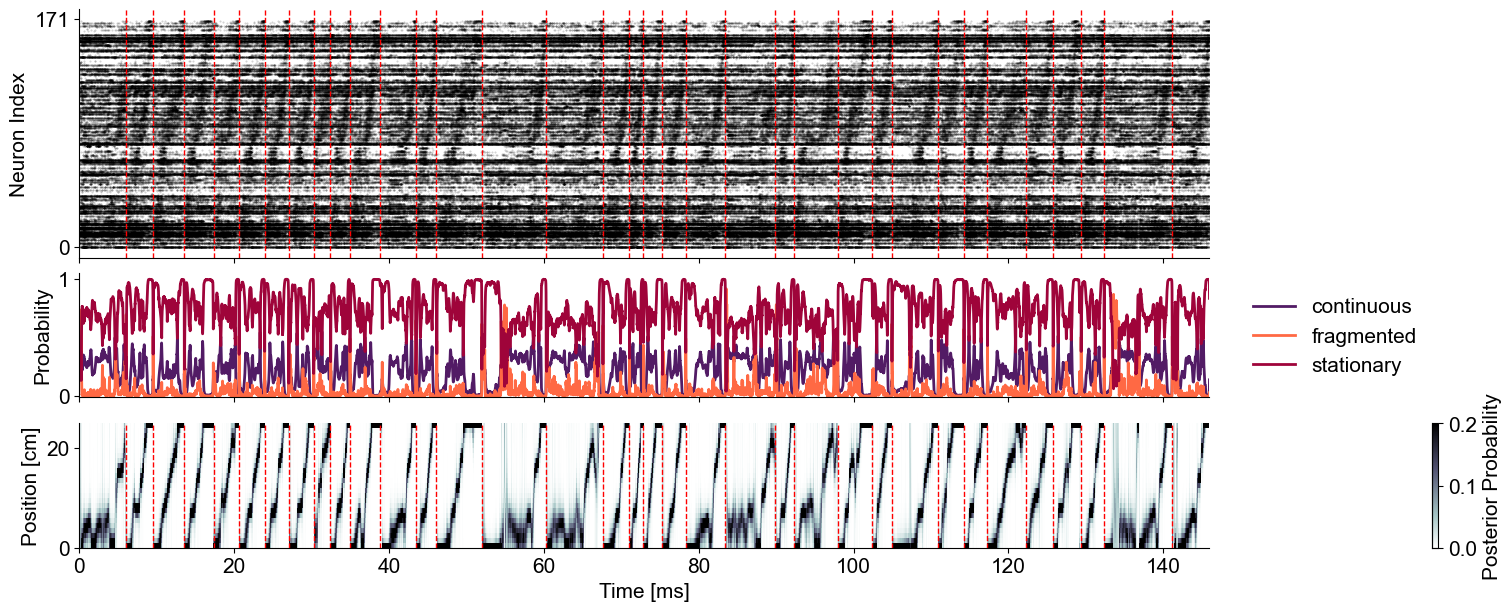

In [149]:
state_names = ['continuous', 'fragmented', 'stationary']
# results = classifier.predict(spikes, time=time, state_names=state_names)

plot_classification(time, spikes, results, h_start)

100%|██████████| 171/171 [00:05<00:00, 31.09it/s]


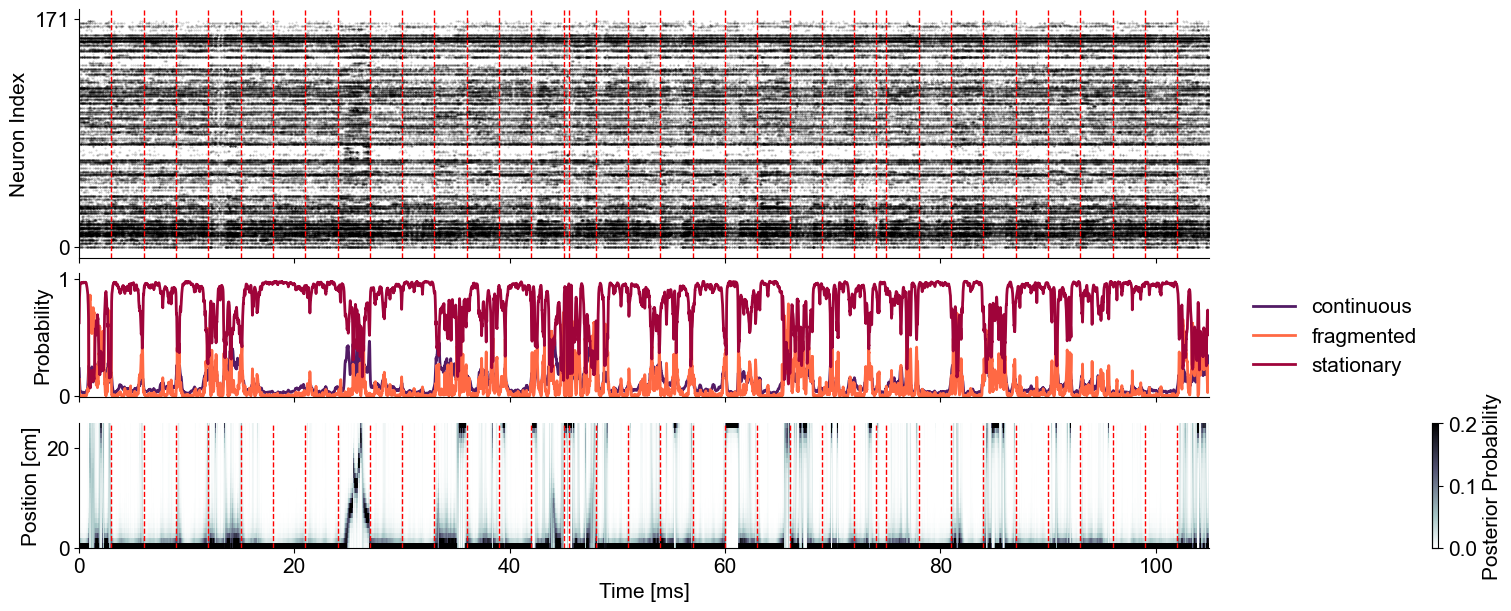

In [150]:
"""Test the decoder on the prehoming period"""
data = np.load(save_path + '\\' + session_name + '_' + cond_names[cond] + '_state_space_decoder_prehomie_data.npz')
pre_time = data['time']
bin_width = data['bin_width'] 
pre_spikes = data['spikes'].T
pre_start = data['h_start']

pre_results = classifier.predict(pre_spikes, time=pre_time, state_names=state_names)

plot_classification(pre_time, pre_spikes, pre_results, pre_start)

100%|██████████| 68/68 [00:00<00:00, 3114.93it/s]


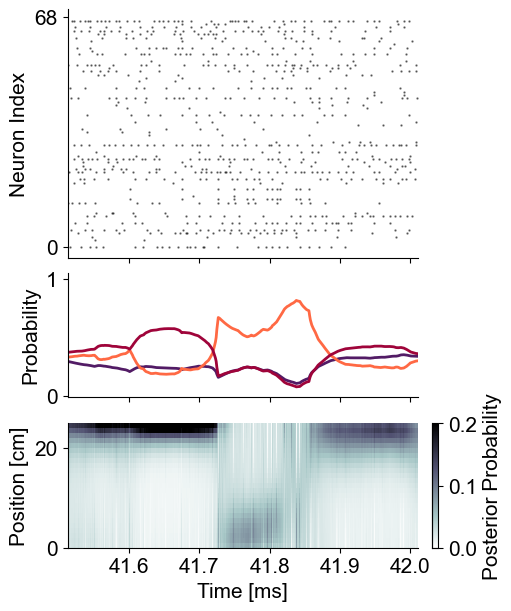

In [242]:
"""Test the decoder on the prehoming period"""
data = np.load(save_path + '\\' + session_name + '_' + cond_names[cond] + '_state_space_decoder_shelter_data.npz')
shel_time = data['time']
bin_width = data['bin_width'] 
shel_spikes = data['spikes'].T
shel_start = data['h_start']

idx = 82

shel_results = classifier.predict(shel_spikes[shel_start[idx]:shel_start[idx+1],:], 
                                  time=shel_time[shel_start[idx]:shel_start[idx+1]], 
                                  state_names=state_names)

def plot_classification(replay_time, test_spikes, results, h_start):
    fig, axes = plt.subplots(3, 1, figsize=(5, 6), sharex=True, constrained_layout=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # plot the spikes
    spike_time_ind, neuron_ind = np.nonzero(test_spikes)
    ax0 = axes[0]
    ax0.scatter(replay_time[spike_time_ind], neuron_ind, color='black', s=.5, alpha = .5, zorder = 1)
    ax0.set_yticks((0, test_spikes.shape[1]))
    ax0.set_ylabel('Neuron Index')

    # plot the replay state prediction
    ax1 = axes[1]
    replay_probability = results.acausal_posterior.sum('position')
    for state, prob in replay_probability.groupby('state'):
        ax1.plot(prob.time, prob.values, linewidth=2, label=state, color=STATE_COLORS[state])
    ax1.set_ylabel('Probability')
    ax1.set_yticks([0, 1])
    ax1.set_ylim((-0.01, 1.05))
    # ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper right', fancybox=False, shadow=False,
    #                ncol=1, frameon=False)
    
    # plot the posterior
    ax2 = axes[2]
    im = results.acausal_posterior.sum('state').plot(x="time", y="position", ax=ax2, cmap="bone_r", vmin = 0, vmax = .2, clip_on=False, add_colorbar=False)
    cbar = fig.colorbar(im, ax=ax2, orientation='vertical', fraction=0.02, pad=0.005)
    cbar.set_label('Posterior Probability')
    ax2.set_ylabel('Position [cm]')
    ax2.set_xlabel('Time [ms]')
    
    if len(h_start) > 0:
        for h in h_start:
            ax0.axvline(h*bin_width, color='red', linestyle='--', linewidth=1)
            ax2.axvline(h*bin_width, color='red', linestyle='--', linewidth=1)

    sns.despine()

plot_classification(shel_time[shel_start[idx]:shel_start[idx+1]], shel_spikes[shel_start[idx]:shel_start[idx+1],:], shel_results, [0, 500])
